n=5, Последний замер: 0.000018s, Среднее время: 0.000018s, СКО: 0.000006s
n=10, Последний замер: 0.000034s, Среднее время: 0.000038s, СКО: 0.000004s
n=15, Последний замер: 0.000068s, Среднее время: 0.000079s, СКО: 0.000014s
n=20, Последний замер: 0.000117s, Среднее время: 0.000113s, СКО: 0.000013s
n=25, Последний замер: 0.000164s, Среднее время: 0.000177s, СКО: 0.000042s
n=100, Последний замер: 0.001377s, Среднее время: 0.001571s, СКО: 0.000117s
n=500, Последний замер: 0.019764s, Среднее время: 0.020027s, СКО: 0.005221s
n=1000, Последний замер: 0.060201s, Среднее время: 0.061579s, СКО: 0.001550s
n=2500, Последний замер: 0.317816s, Среднее время: 0.323380s, СКО: 0.003718s
n=5000, Последний замер: 1.195856s, Среднее время: 1.180337s, СКО: 0.024658s


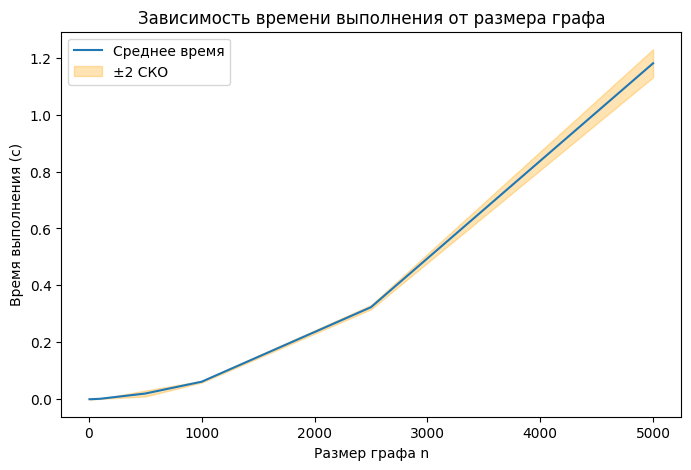

n=20, Последний замер: 0.000094s, Среднее время: 0.000103s, СКО: 0.000021s


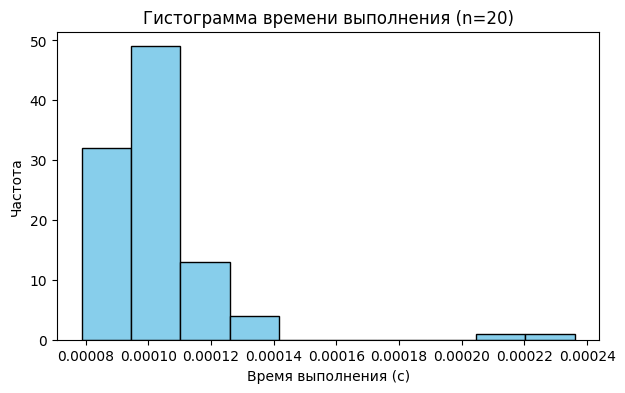

Тест на нормальность: статистика=119.742, p-value=0.000
Гипотеза о нормальном распределении времени отвергается
Среднее время выполнения для n=20 ≈ 0.10 мс


In [31]:
import time
import random
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import normaltest

def game(graph, weights, top_k=50):
    n = len(graph)
    blocked = set()
    
    p1 = set()
    p2 = set()
    turn_p2 = False
    
    def get_candidates():
        candidates = []
        for v in graph:
            if v not in blocked:
                blocked_weight = sum(weights[u] for u in graph[v] if u not in blocked)
                score = weights[v] + blocked_weight
                candidates.append((score, v))
        candidates.sort(reverse=True)
        return [v for _, v in candidates[:top_k]]
    
    while True:
        candidates = get_candidates()
        if not candidates:
            break
        
        best_v = None
        best_score = float('-inf')
        
        for v in candidates:
            my_gain = weights[v]
            blocked_gain = sum(weights[u] for u in graph[v] if u not in blocked)
            
            new_blocked = blocked | {v} | set(graph[v])
            opp_moves = [u for u in graph if u not in new_blocked]
            opp_best = max([weights[u] for u in opp_moves], default=0)
            
            score = my_gain + blocked_gain - opp_best
            if score > best_score:
                best_score = score
                best_v = v
        
        if turn_p2:
            p2.add(best_v)
        else:
            p1.add(best_v)
        
        blocked.add(best_v)
        blocked.update(graph[best_v])
        
        turn_p2 = not turn_p2
    
    sum_p1 = sum(weights[v] for v in p1)
    sum_p2 = sum(weights[v] for v in p2)
    
    return sum_p1, sum_p2

def generate_random_graph(n, edge_prob=0.3):
    graph = {i: [] for i in range(n)}
    weights = {i: random.randint(1, 20) for i in range(n)}
    for i in range(n):
        for j in range(i+1, n):
            if random.random() < edge_prob:
                graph[i].append(j)
                graph[j].append(i)
    return graph, weights

def measure_times(n_trials, n):
    times = []
    for _ in range(n_trials):
        graph, weights = generate_random_graph(n)
        start = time.time()
        game(graph, weights)
        end = time.time()
        times.append(end - start)
    times = np.array(times)
    mean_time = times.mean()
    std_time = times.std()
    last_time = times[-1]
    print(f"n={n}, Последний замер: {last_time:.6f}s, Среднее время: {mean_time:.6f}s, СКО: {std_time:.6f}s")
    return times, mean_time, std_time

sizes = [5, 10, 15, 20, 25, 100, 500, 1000, 2500, 5000]
mean_times = []
std_times = []

for n in sizes:
    times, mean_t, std_t = measure_times(n_trials=20, n=n)
    mean_times.append(mean_t)
    std_times.append(std_t)

plt.figure(figsize=(8,5))
mean_times = np.array(mean_times)
std_times = np.array(std_times)
plt.plot(sizes, mean_times, label='Среднее время')
plt.fill_between(sizes, mean_times-2*std_times, mean_times+2*std_times, color='orange', alpha=0.3, label='±2 СКО')
plt.xlabel('Размер графа n')
plt.ylabel('Время выполнения (с)')
plt.title('Зависимость времени выполнения от размера графа')
plt.legend()
plt.show()

times, mean_t, std_t = measure_times(n_trials=100, n=20)
plt.figure(figsize=(7,4))
plt.hist(times, bins=10, color='skyblue', edgecolor='black')
plt.xlabel('Время выполнения (с)')
plt.ylabel('Частота')
plt.title('Гистограмма времени выполнения (n=20)')
plt.show()

stat, p_value = normaltest(times)
print(f"Тест на нормальность: статистика={stat:.3f}, p-value={p_value:.3f}")
if p_value > 0.05:
    print("Можно принять гипотезу о нормальном распределении времени")
else:
    print("Гипотеза о нормальном распределении времени отвергается")

avg_time_ms = mean_t * 1000
print(f"Среднее время выполнения для n=20 ≈ {avg_time_ms:.2f} мс")